In [1]:
import numpy as np
from lensing_data_class import LensingData
from cluster_local_tidy import ClusterLensing
import os
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.cosmology import FlatLambdaCDM
import lenstronomy.Util.constants as const
import pandas as pd
import corner
import arviz as az
import pathlib

In [2]:
import warnings

# Suppressing the lenstronomy warning on astropy.cosmology
from lenstronomy.LensModel.lens_model import LensModel
warnings.filterwarnings("ignore", category=UserWarning, module='lenstronomy.LensModel.lens_model')

# Lens data

scenarios = {
        '1': 'abell370',
        '2': 'abell2744',
        '3': 'abells1063',
        '4': 'macs0416',
        '5': 'macs0717',
        '6': 'macs1149'
    }

full_cluster_names = {
        'abell370': 'Abell 370',
        'abell2744': 'Abell 2744',
        'abells1063': 'Abell S1063',
        'macs0416': 'MACS J0416.1-2403',
        'macs0717': 'MACS J0717.5+3745',
        'macs1149': 'MACS J1149.5+2223'
    }

# Initialize lists to store the data arrays
datax_list = []
datay_list = []
data_psi_list = []
data_sigma_dt_list = []

for i in scenarios:
    clustername = scenarios[i]
    full_cluster_name = full_cluster_names[clustername]

    file_dir = os.getcwd()
    fits_filex = os.path.join(
        file_dir,
        f'GCdata/{full_cluster_name}/cats copy/hlsp_frontier_model_{clustername}_cats_v4_x-arcsec-deflect.fits'
    )
    fits_filey = os.path.join(
        file_dir,
        f'GCdata/{full_cluster_name}/cats copy/hlsp_frontier_model_{clustername}_cats_v4_y-arcsec-deflect.fits'
    )
    psi_file = os.path.join(
        file_dir,
        f'GCdata/{full_cluster_name}/cats copy/hlsp_frontier_model_{clustername}_cats_v4_psi.fits'
    )
    sigma_dt_file = os.path.join(
        file_dir,
        f'GCdata/{full_cluster_name}/cats copy/hlsp_frontier_model_{clustername}_cats_v4_sigma_dt.fits'
    )   

    with fits.open(fits_filex) as hdulx, fits.open(fits_filey) as hduly, fits.open(psi_file) as hdul_psi, fits.open(sigma_dt_file) as hdul_sigma_dt:
        datax = hdulx[0].data
        datay = hduly[0].data
        data_psi = hdul_psi[0].data
        data_sigma_dt = hdul_sigma_dt[0].data

        # Append the data arrays to the lists
        datax_list.append(datax)
        datay_list.append(datay)
        data_psi_list.append(data_psi)
        data_sigma_dt_list.append(data_sigma_dt)

# getting the pixel scale list
pixscale_list = [0.2, 0.3, 0.2, 0.3, 0.8, 0.5]
z_l_list = [0.375, 0.308, 0.351, 0.397, 0.545, 0.543]
lensing_data = LensingData(
    alpha_maps_x=datax_list,
    alpha_maps_y=datay_list,
    lens_potential_maps=data_psi_list,
    uncertainty_dt=data_sigma_dt_list,
    pixscale = pixscale_list,
    z_l_list = z_l_list, # Lens redshifts for the two clusters
    # We can use the default x_center, y_center, and search_window_list
    # or override them if needed.
)

# --- 3. Initialize the Main Analysis Class ---
# z_s_ref is a reference source redshift used for initial scaling calculations.
# It can be an estimate of the source's redshift.
z_s_ref = 1.5 
cluster_system = ClusterLensing(data=lensing_data, z_s_ref=z_s_ref)

print("Setup complete. Lensing system initialized.")

Setup complete. Lensing system initialized.


Number of posterior odds values with chi_sq <= 5.5: 48


Text(0.5, 0, '$log_{10} \\mathcal{B}$ ($\\delta \\chi^2$)')

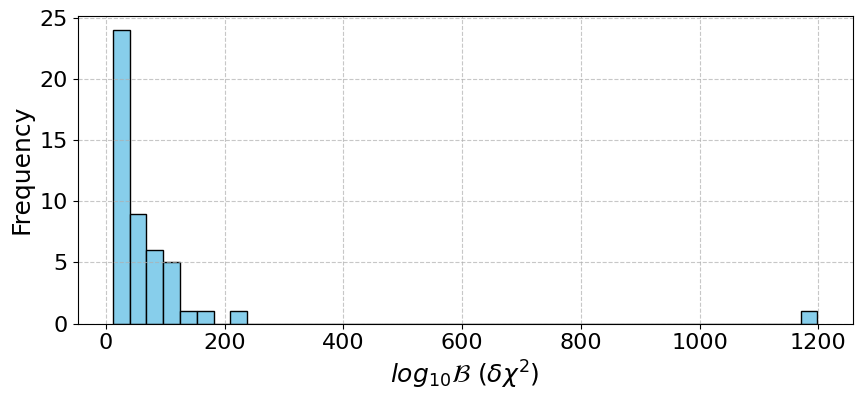

In [25]:
# making the bayes factor histogram plot
data = pd.read_csv('src_pos_tidy_xy.csv')
posterior_odds = data['posterior_odds'].values
# opt out the posterior_odds values if the value of chi_sq in the same row is larger than 100
chi_sq_values = data['chi_sq'].values
posterior_odds = posterior_odds[chi_sq_values <= 5.5] # type: ignore
print(f"Number of posterior odds values with chi_sq <= 5.5: {len(posterior_odds)}")
# posterior_odds are in ln base, change to log 10 base
posterior_odds = np.log10(np.e) * posterior_odds
#print(posterior_odds)

# getting the bin number using Freedman-Diaconis rule
def freedman_diaconis(data):
    q75, q25 = np.percentile(data, [75 ,25])
    iqr = q75 - q25
    bin_width = 2 * iqr * len(data) ** (-1/3)
    bin_count = int((data.max() - data.min()) / bin_width)
    return bin_count


plt.figure(figsize=(10, 4))
plt.hist(posterior_odds, color='skyblue', edgecolor='black', bins=freedman_diaconis(posterior_odds))
# add grid lines in x and y direction
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# set the font size of the ticks
plt.tick_params(axis='both', which='major', labelsize=16)
plt.ylabel('Frequency', fontsize=18)
plt.xlabel(r'$log_{10} \mathcal{B}$ ($\delta \chi^2$)', fontsize=18)

#plt.savefig('Report images sem2/new/posterior_odds_histogram_xyz.pdf', bbox_inches='tight')


In [12]:
import re
from pathlib import Path

_FLOAT = r"[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?"

RE_FX = re.compile(rf"f\(x\)\s*=\s*({_FLOAT})")
RE_CLUSTER_BEST = re.compile(r"^Cluster\s+(\d+)\s+DE best chi\^2:")
RE_CLUSTER_HEADER = re.compile(r"^--- Running DE for Cluster\s+(\d+)\s+---")

def fx_before_best(log_text: str, clusters=range(6)):
    clusters = set(clusters)
    fx_before = {}
    prev_line = None
    current_cluster = None
    last_fx_in_cluster = {}

    for raw in log_text.splitlines():
        line = raw

        mh = RE_CLUSTER_HEADER.match(line)
        if mh:
            current_cluster = int(mh.group(1))

        mfx = RE_FX.search(line)
        if mfx and current_cluster is not None:
            last_fx_in_cluster[current_cluster] = float(mfx.group(1))

        mb = RE_CLUSTER_BEST.match(line)
        if mb:
            k = int(mb.group(1))
            if k in clusters:
                val = None
                if prev_line is not None:
                    mprev = RE_FX.search(prev_line)
                    if mprev:
                        val = float(mprev.group(1))
                if val is None:
                    val = last_fx_in_cluster.get(k)
                fx_before[k] = val

        prev_line = line

    return fx_before

def fx_before_best_from_file(path, clusterno=6, encoding="utf-8"):
    clusters = set(range(clusterno))
    text = Path(path).read_text(encoding=encoding, errors="replace")
    return fx_before_best(text, clusters=clusters)


In [17]:
out = fx_before_best_from_file("/home/dices/Research/GWlensing_Brian/outputs/with_z/row0.out")
values = np.array(list(out.values()))
values*= np.log10(np.e)
print(f"Values of f(x) before best chi^2 for clusters 0-5: {values}")

Values of f(x) before best chi^2 for clusters 0-5: [7.00249810e-03 1.30288345e+03 7.38118051e+01 2.84906735e+01
 4.78885943e+01 1.16041689e+02]


In [18]:
bayes = values - values.min()
print(f"Bayes factors (relative to best cluster): {bayes}")

Bayes factors (relative to best cluster): [   0.         1302.87644321   73.80480255   28.48367102   47.88159181
  116.03468685]


Fitted normal distribution parameters: μ=313.8, σ=495.4


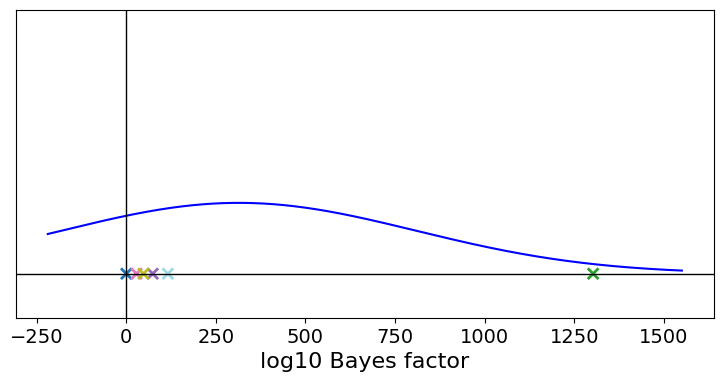

In [19]:
from scipy.stats import norm
fig, ax = plt.subplots(figsize=(9, 4))
zeros = np.zeros_like(bayes, dtype=float)

# fit a normal distribution to the bayes factors and plot the normal distribution curve
bayes_without_min = np.delete(bayes, np.argmin(bayes))
mu, sigma = norm.fit(bayes_without_min)
dist = norm(loc=mu, scale=sigma)
grid = np.linspace(bayes_without_min.min()-0.5*sigma, bayes_without_min.max()+0.5*sigma, 2000)
pdf = dist.pdf(grid)
ax.plot(grid, pdf, color='blue', label=f'Normal fit: μ={mu:.4g}, σ={sigma:.4g}')
print(f"Fitted normal distribution parameters: μ={mu:.4g}, σ={sigma:.4g}")

# one different color per point
cvals = np.arange(len(bayes))
sc = ax.scatter(bayes, zeros, c=cvals, cmap="tab20", marker="x", linewidths=2, s =60)

ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)
ax.set_ylim(-0.0005, 0.003)
ax.set_yticks([])
ax.tick_params(labelsize=14)
ax.set_xlabel("log10 Bayes factor", fontsize=16)

plt.show()

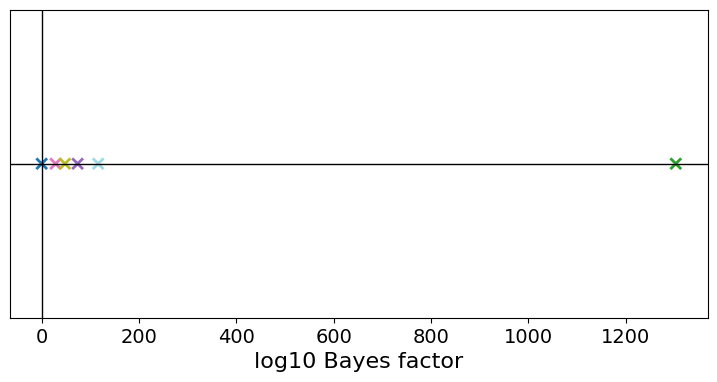

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
zeros = np.zeros_like(bayes, dtype=float)

# one different color per point
cvals = np.arange(len(bayes))
sc = ax.scatter(bayes, zeros, c=cvals, cmap="tab20", marker="x", linewidths=2, s =60)

ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)
ax.set_ylim(-0.001, 0.001)
ax.set_yticks([])
ax.tick_params(labelsize=14)
ax.set_xlabel("log10 Bayes factor", fontsize=16)

plt.show()

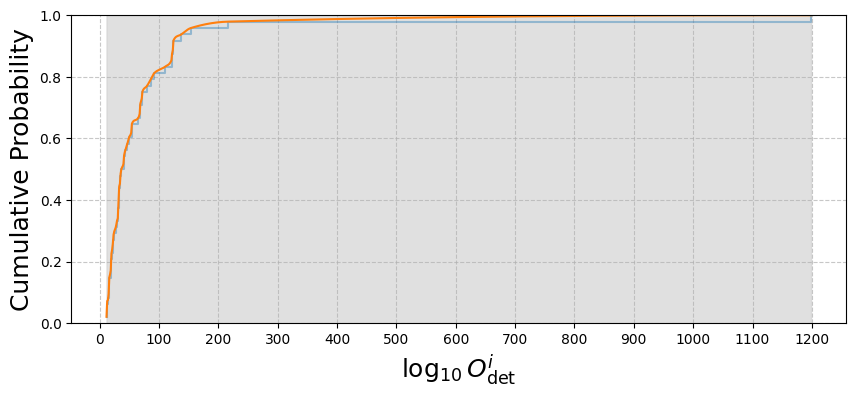

In [31]:
from scipy.interpolate import PchipInterpolator

x = np.asarray(posterior_odds, dtype=float)
x = x[np.isfinite(x)]
xs = np.sort(x)
n = xs.size

# ECDF (step)
ecdf = np.arange(1, n + 1) / n

# PCHIP needs strictly increasing x -> compress duplicates:
xu = np.unique(xs)
yu = np.searchsorted(xs, xu, side="right") / n  # ECDF value at last duplicate

pchip = PchipInterpolator(xu, yu)  # monotone, smooth
grid = np.linspace(xu[0], xu[-1], 1000)
ecdf_smooth = np.clip(pchip(grid), 0, 1)

plt.figure(figsize=(10, 4))
plt.step(xs, ecdf, where="post", alpha=0.4)
plt.plot(grid, ecdf_smooth)
# fill the whole space after x > 5 with a grey color
plt.fill_between(grid, 0, 1.0, where=grid > 5, color='lightgray', alpha=0.7, interpolate=True)
plt.grid(axis="both", linestyle="--", alpha=0.7)
plt.ylabel("Cumulative Probability", fontsize=18)
plt.xlabel(r"$\log_{10}O^i_\text{det}$", fontsize=18)
plt.xticks(np.arange(0, 1300, 100))
plt.ylim(0, 1.00)
plt.savefig('Report images sem2/new/posterior_odds_cdf_xy.pdf', bbox_inches='tight')